In [ ]:
from backtesting import Backtest, Strategy
from backtesting.test import GOOG, SMA
from backtesting.lib import crossover, plot_heatmaps
import matplotlib.pyplot as plt

In [4]:
class Sma4Cross(Strategy):
    n1 =50
    n2=100
    n_enter =20
    n_exit =10

    def init(self):
        self.sma1 = self.I(SMA, self.data.Close, self.n1)
        self.sma2 = self.I(SMA, self.data.Close, self.n2)
        self.sma_enter = self.I(SMA, self.data.Close, self.n_enter)
        self.sma_exit = self.I(SMA, self.data.Close, self.n_exit)
    
    def next(self):
        if not self.position:
            if self.sma1 > self.sma2:
                if crossover(self.data.Close, self.sma_enter):
                    self.buy()

            else:
                if crossover(self.sma_enter, self.data.Close):
                    self.sell()
        else:
            if (self.position.is_long and crossover(self.sma_exit,self.data.Close)) or (self.position.is_short and crossover(self.data.Close, self.sma_exit)):
                    self.position.close()
            

In [8]:
bt=Backtest(GOOG, Sma4Cross,commission=.002)

stats,heatmap=bt.optimize(n1=range(10,110,10),
                          n2=range(20,210,20),  
                          n_enter=range(15,30,5),
                          n_exit=range(10,25,5),
                          constraint=lambda p: p.n_exit<p.n_enter< p.n1 < p.n2,
                          maximize='Equity Final [$]',
                          return_heatmap=True)


c:\Users\admin\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\backtesting\backtesting.py:1624: UserWarning: Searching for best of 345 configurations.
  output = _optimize_grid()
c:\Users\admin\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\backtesting\backtesting.py:1624: RuntimeWarning: If you want to use multi-process optimization with `multiprocessing.get_start_method() == 'spawn'` (e.g. on Windows),set `backtesting.Pool = multiprocessing.Pool` (or of the desired context) and hide `bt.optimize()` call behind a `if __name__ == '__main__'` guard. Currently using thread-based paralellism, which might be slightly slower for non-numpy / non-GIL-releasing code. See https://github.com/kernc/backtesting.py/issues/1256
  output = _optimize_grid()
c:\Users\admin\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\backtesting\backtesting.py:1637: UserWarning: Some trades remain open at the end of backtest. Use `Backtest(..., finalize_trades=True)` to close them and 

In [12]:
heatmap

n1   n2   n_enter  n_exit
20   40   15       10         7479.37094
     60   15       10         8448.64150
     80   15       10         8348.38338
     100  15       10         9283.02076
     120  15       10        10766.15832
                                ...     
100  200  20       10         9736.19452
                   15        14234.93482
          25       10         7732.77344
                   15         8406.17086
                   20         7337.87622
Name: Equity Final [$], Length: 345, dtype: float64

In [ ]:
# show top 3 combinations, as of we are sorting a Series
heatmap.sort_values().iloc[-3:]

n1  n2   n_enter  n_exit
40  60   25       15        18600.92078
50  120  20       15        18637.80318
40  160  20       15        19230.95522
Name: Equity Final [$], dtype: float64

In [ ]:
# we can alos convert it into a DataFrame and sort by the value column
# 1. Convert to a DataFrame (turns index labels into columns)
df = heatmap.reset_index()

# 2. Rename the last column (since it was a Series, it usually gets a generic name like 0)
df.columns = [*df.columns[:-1], 'Equity Final [$]']

# 3. Sort by that new columnm or any other column
df = df.sort_values(by='Equity Final [$]', ascending=True)

,n1,n2,n_enter,n_exit,Equity Final [$]
174,60,120,25,10,4836.27206
216,70,120,25,10,4970.84186
210,70,100,25,10,5038.61810
222,70,140,25,10,5198.48930
246,80,100,25,10,5283.10610
...,...,...,...,...,...
317,100,120,20,15,17514.47418
125,50,100,20,15,17733.71148
67,40,60,25,15,18600.92078
131,50,120,20,15,18637.80318


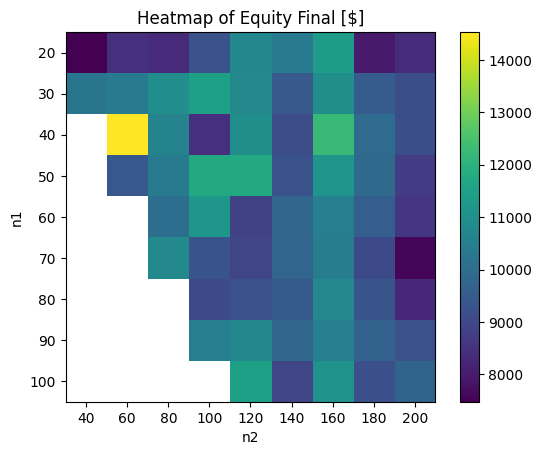

In [25]:
hm = heatmap.groupby(['n1', 'n2']).mean().unstack()  # reshape for heatmap
fig, ax = plt.subplots()
im = ax.imshow(hm,cmap="viridis")
_=(ax.set_xticks(range(len(hm.columns)),labels=hm.columns),
                                  ax.set_yticks(range(len(hm.index)),labels=hm.index),
                                  ax.set_xlabel('n2'),
                                    ax.set_ylabel('n1'),
                                    ax.set_title('Heatmap of Equity Final [$]'),
                                    plt.colorbar(im, ax=ax),)



In [27]:
from backtesting.lib import plot_heatmaps

plot_heatmaps(heatmap, agg="mean")



GridPlot(id='p1701', ...)